# Chapter 4 - Sample Weights

## Preparation

In [172]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample, shuffle
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

from utils.sampling_bars import dollar_bar
from utils.multiprocess import mpPandasObj

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

dollar_bars = dollar_bar(df)

print(f"{df.shape} --> {dollar_bars.shape}")

(5063527, 8) --> (1443691, 8)


In [2]:
dollar_bars.head()

,price,bid,ask,vol,dollar_vol,trade_count,price_high,price_low
date,,,,,,,,
2009-09-28 09:31:50,50.75,50.73,50.76,300.0,15225.00,1.0,50.75,50.75
2009-09-28 09:33:02,50.81,50.80,50.81,800.0,40648.00,2.0,50.81,50.81
2009-09-28 09:34:04,50.82,50.80,50.82,100.0,5082.00,1.0,50.82,50.82
2009-09-28 09:38:28,50.81,50.79,50.81,195.0,9907.95,1.0,50.81,50.81
2009-09-28 09:42:17,50.85,50.83,50.85,200.0,10170.00,2.0,50.85,50.85


In [5]:
close = dollar_bars["price"].sort_index()

## 1. In Chapter 3, we denoted as t1 a pandas series of timestamps where the first  barrier was touched, and the index was the timestamp of the observation. This was the output of the getEvents function.

### a. Compute a t1 series on dollar bars derived from E-mini S&P 500 futures tick data.

In [156]:
def get_daily_vol(close, span0=100):
    """Compute exponentially weighted daily return volatility."""
    close = close.sort_index()
    close = close[~close.index.duplicated(keep="last")]

    prev_pos = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    valid = prev_pos > 0

    current_pos = np.arange(len(close))[valid]
    prev_pos = prev_pos[valid] - 1

    returns = pd.Series(
        close.iloc[current_pos].to_numpy() / close.iloc[prev_pos].to_numpy() - 1,
        index=close.index[current_pos],
        name="daily_vol",
    )
    return returns.ewm(span=span0).std().dropna()

def symmetric_cusum_filter(close, threshold):
    """Apply a symmetric CUSUM filter to log returns."""
    close = close.sort_index()
    log_ret = np.log(close).diff().dropna()

    if isinstance(threshold, pd.DataFrame):
        if threshold.shape[1] != 1:
            raise ValueError("threshold DataFrame must have exactly one column")
        threshold = threshold.iloc[:, 0]

    if isinstance(threshold, pd.Series):
        threshold_values = threshold.sort_index().reindex(log_ret.index).ffill().to_numpy()
    else:
        threshold_values = np.full(log_ret.shape[0], threshold)

    s_pos, s_neg = 0.0, 0.0
    t_events = []
    for t, ret, h in zip(log_ret.index, log_ret.to_numpy(), threshold_values):
        if pd.isna(h) or h <= 0:
            continue

        s_pos = max(0.0, s_pos + ret)
        s_neg = min(0.0, s_neg + ret)

        if s_pos > h:
            s_pos = 0.0
            t_events.append(t)
        elif s_neg < -h:
            s_neg = 0.0
            t_events.append(t)
    return pd.DatetimeIndex(t_events)


def get_vertical_bars(close, t_events, num_days=1):
    t1 = close.index.searchsorted(t_events + pd.Timedelta(days=num_days))
    t1 = t1[t1 < close.shape[0]]
    t1 = pd.Series(close.index[t1], index=t_events[:t1.shape[0]]) # NaNs at the end
    return t1


# TRIPLE-BARRIER LABELING METHOD
def apply_pt_sl_on_t1(close, events, pt_sl, molecule):
    """
    For example, from applied_pt_sl.csv:

    2010-05-06 14:46:25,2010-05-07 14:50:01,2010-05-06 14:48:37,2010-05-06 14:46:27
    For the event starting at 2010-05-06 14:46:25:

    vertical barrier: 2010-05-07 14:50:01
    stop loss touched: 2010-05-06 14:48:37
    profit taking touched: 2010-05-06 14:46:27
    
    Since pt happens first, the event should end at 2010-05-06 14:46:27.
    """
    """Apply stop loss on t1."""
    events_ = events.copy().loc[molecule]
    out = events_[['t1']].copy(deep=True)

    # upper limit (profit taking)
    if pt_sl[0] > 0:
        pt = pt_sl[0] * events_['target']
    else:
        pt = pd.Series(index=events.index) # NaNs
    
    # lower limit (stop loss)
    if pt_sl[1] > 0:
        sl = -pt_sl[1] * events_['target']
    else:
        sl = pd.Series(index=events.index) #  NaNs
    
    for loc, t1_val in events_['t1'].fillna(close.index[-1]).items():
        df0 = close[loc:t1_val] # path prices
        df0 = (df0 / close[loc] - 1) * events_.at[loc, 'side'] # path linear returns
        out.loc[loc, 'sl'] = df0[df0<sl[loc]].index.min() # earliest stop loss
        out.loc[loc, 'pt'] = df0[df0>pt[loc]].index.min() # earliest profit take

    
    # The output from this function is a pandas dataframe containing 
    # the timestamps (if any) at which each barrier was touched.
    return out

def get_events(close, t_events, pt_sl, target, min_ret, num_threads=1, t1=None, side=None):
    # Aligns target to t_events
    # Only events whose target is larger than min_ret are kept.
    target = target.loc[t_events]
    target = target[target > min_ret]
    if t1 is None:
        t1 = pd.Series(pd.NaT, index=t_events)
    
    if side is None:
        # default long side
        side_, pt_sl_ = pd.Series(1.0, index=target.index), [pt_sl[0], pt_sl[0]]
    else:
        side_, pt_sl_ = side.loc[target.index], pt_sl[:2]
    
    events = pd.concat({'t1': t1, 'target': target, 'side': side_}, axis=1).dropna(subset=['target'])
    barriers = mpPandasObj(func=apply_pt_sl_on_t1, pdObj=('molecule', events.index), numThreads=num_threads, close=close, events=events, pt_sl=pt_sl_)
    
    barriers.to_csv('applied_pt_sl.csv')
    # Replaces events['t1'] with the earliest touched barrier
    # However, we don't know which barrier is touched
    barriers = barriers.dropna(how='all')
    events['t1'] = barriers.min(axis=1)
    events['barrier'] = barriers.idxmin(axis=1)


    if side is None:
        events = events.drop('side', axis=1)
    
    return events


def get_bins(events, close):
    events_ = events.dropna(subset=['t1'])

    px = events_.index.union(events_['t1'].values).drop_duplicates()
    px = close.reindex(px, method='bfill')

    out = pd.DataFrame(index=events_.index)
    out['ret'] = px.loc[events_['t1'].values].values / px.loc[events_.index] - 1
    if 'side' in events_:
        out['ret'] *= events_['side']  # meta-labeling


    out['bin'] = events_['barrier'].map({
        'pt': 1,
        'sl': -1,
        't1': 0,
    })
    
    if 'side' in events_:
        out.loc[out['ret'] <= 0, 'bin'] = 0
        out['side'] = events['side']

    return out

In [ ]:
daily_vol = get_daily_vol(close, span0=10000)
t_events = symmetric_cusum_filter(close, daily_vol)
vertical_bars = get_vertical_bars(close, t_events, num_days=1) # t1 in the text book

abs_return = close.pct_change().abs()

events = get_events(close, t_events=t_events, pt_sl=[1,1], t1=vertical_bars, num_threads=1, target=daily_vol, min_ret=0.01)

events.head()

,t1,target,barrier
2009-10-02 09:29:12,2009-10-05 09:30:01,0.010093,t1
2009-10-02 10:34:44,2009-10-05 09:30:01,0.011114,t1
2009-10-05 09:51:42,2009-10-05 14:56:12,0.010125,pt
2009-10-05 14:46:54,2009-10-06 09:41:28,0.012126,pt
2009-10-06 09:41:28,2009-10-07 09:42:07,0.013684,t1


In [113]:
events.tail()

,t1,target,barrier
2025-05-27 09:29:59,2025-05-28 09:30:00,0.014298,t1
2025-06-03 11:25:02,2025-06-04 11:26:29,0.012609,t1
2025-06-06 09:38:54,2025-06-09 09:30:00,0.011879,t1
2025-06-10 13:11:38,2025-06-11 13:13:09,0.011246,t1
2025-06-13 14:27:43,2025-06-16 09:30:00,0.010474,t1


In [114]:
type(events)

pandas.DataFrame

In [115]:
events.shape

(1611, 3)

### b. Apply the function mpNumCoEvents to compute the number of  overlapping outcomes at each point in time.

In [116]:
def mp_num_concurrent_events(close_idx, t1, molecule):
    '''
    Compute the number of concurrent events per bar.
    +molecule[0] is the date of the first event on which the weight will be computed
    +molecule[-1] is the date of the last event on which the weight will be computed
    Any event that starts before t1[molecule].max() impacts the count.
    '''
    # 1) find events that span the period [molecule[0], molecule[-1]]
    t1 = t1.fillna(close_idx[-1]) # unclosed events still must impact other weights
    t1 = t1[t1 >= molecule[0]] # events that end at or after molecule[0]
    t1 = t1.loc[:t1[molecule].max()] # events that start at or before t1[molecule].max()
    # 2) count events spanning a bar
    iloc = close_idx.searchsorted(np.array([t1.index[0], t1.max()]))
    count = pd.Series(0, index=close_idx[iloc[0]:iloc[1]+1])
    for tIn, tOut in t1.items():  # items() instead of iteritems()
        count.loc[tIn:tOut] += 1.0
    return count.loc[molecule[0]:t1[molecule].max()]

In [123]:
concurrent_events = mpPandasObj(mp_num_concurrent_events, pdObj=('molecule', events.index), numThreads=1, close_idx=close.index, t1=events['t1'])
concurrent_events = concurrent_events.loc[~concurrent_events.index.duplicated(keep='last')]
concurrent_events = concurrent_events.reindex(close.index).fillna(0)

In [124]:
concurrent_events.head()

date
2009-09-28 09:31:50    0.0
2009-09-28 09:33:02    0.0
2009-09-28 09:34:04    0.0
2009-09-28 09:38:28    0.0
2009-09-28 09:42:17    0.0
dtype: float64

In [125]:
concurrent_events.shape

(1443691,)

In [126]:
# The value indicates the number of concurrent events at each point in time.
concurrent_events.value_counts()

0.0    1043799
1.0     324453
2.0      69824
3.0       5524
4.0         89
5.0          2
Name: count, dtype: int64

### c. Plot the time series of the number of concurrent labels on the primary  axis, and the time series of exponentially weighted moving standard deviation of returns on the secondary axis.

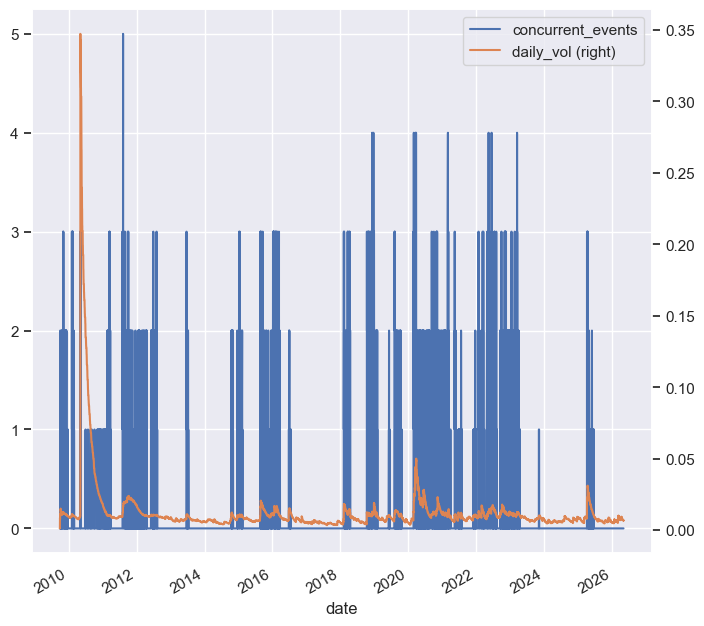

In [127]:
to_plot = pd.DataFrame({'concurrent_events': concurrent_events, 'daily_vol':daily_vol}).dropna()
to_plot.plot(secondary_y='daily_vol');

### d. Produce a scatterplot of the number of concurrent labels (x-axis) and the exponentially weighted moving standard deviation of returns (y-axis). Can you appreciate a relationship?

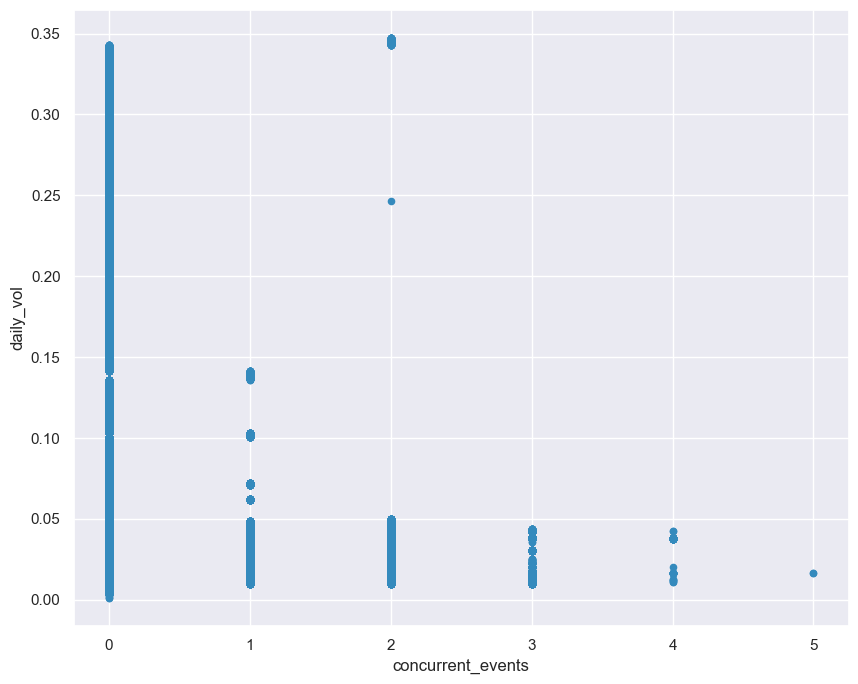

In [128]:
to_plot.plot.scatter(x='concurrent_events', y='daily_vol', figsize=(10, 8))
plt.show()

## 2. Using the function mpSampleTW, compute the average uniqueness of each  label. What is the first-order serial correlation, AR(1), of this time series? Is it statistically significant? Why?

In [132]:
def mp_sample_tw(t1, concurrent_events, molecule):
    # Derive average uniqueness over the event's lifespan
    weights = pd.Series(index=molecule)
    for tIn, tOut in t1.loc[weights.index].items():
        weights.loc[tIn] = (1.0 / concurrent_events.loc[tIn:tOut]).mean()
    return weights

In [140]:
average_uniqueness = mpPandasObj(mp_sample_tw, pdObj=('molecule', events.index), numThreads=1, t1=events['t1'], concurrent_events=concurrent_events)

average_uniqueness.head()

2009-10-02 09:29:12    0.628205
2009-10-02 10:34:44    0.500000
2009-10-05 09:51:42    0.974747
2009-10-05 14:46:54    0.951613
2009-10-06 09:41:28    0.996403
dtype: float64

In [141]:
average_uniqueness.tail()

2025-05-27 09:29:59    0.998503
2025-06-03 11:25:02    1.000000
2025-06-06 09:38:54    1.000000
2025-06-10 13:11:38    1.000000
2025-06-13 14:27:43    1.000000
dtype: float64

In [142]:
average_uniqueness.shape

(1611,)

In [145]:
f"average average uniqueness: {average_uniqueness.mean()}"

'average average uniqueness: 0.8228141128138785'

In [143]:
average_uniqueness.autocorr()

np.float64(0.5855093887319682)

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

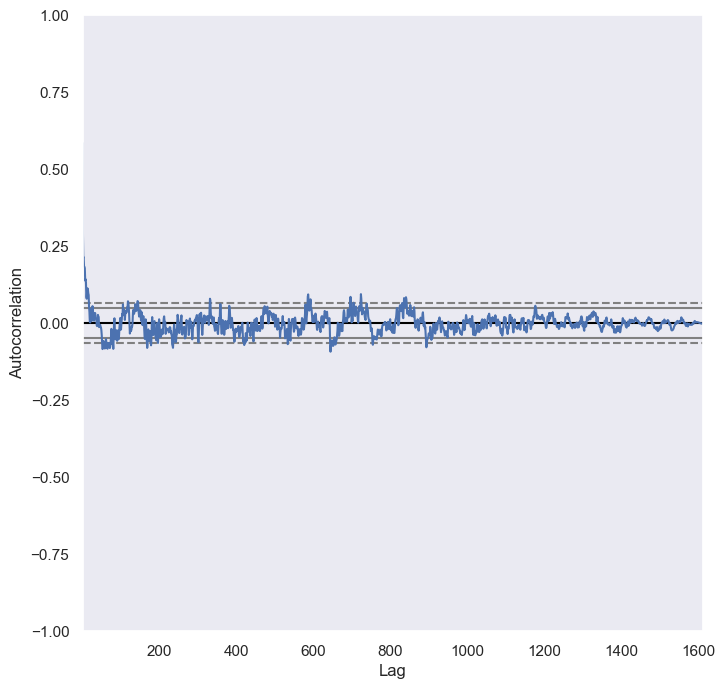

In [144]:
pd.plotting.autocorrelation_plot(average_uniqueness)

Conceptually, yes, it is expected to be significant. Average uniqueness is computed from overlapping event lifespans and concurrent event counts. Adjacent event start times often share many of the same bars and concurrency structure, so the uniqueness values are mechanically persistent. That means the significance is not necessarily evidence of a tradable signal; it mostly reflects overlapping labels and event clustering.

## 3. Fit a random forrest to a financial dataset where $I^{-1} \sum_{i=1}^{I} u_i  \ll 1$

#### Preparation

In [255]:
min_uniqueness = 10000
min_start_time = '2009-01-01'
min_end_time = '2012-12-31'

for i in range(9, 27):
    for j in range(i+1, 28):
        try:
            # Get a subset of the dollar bars (2009 - 2012)
            start_time = f'20{i if i >= 10 else "0" + str(i)}-01-01'
            end_time = f'20{j if j >= 10 else "0" + str(j)}-01-01'

            dollar_bars_subset = dollar_bars[dollar_bars.index < end_time]
            dollar_bars_subset = dollar_bars_subset.loc[dollar_bars_subset.index >= start_time]
            close_subset = dollar_bars_subset["price"].sort_index()

            # Trend-following strategy: moving average crossover
            # 1. Compute short-term and long-term moving averages
            short_window = 50
            long_window = 200

            short_ma = close_subset.rolling(window=short_window, min_periods=1).mean()
            long_ma = close_subset.rolling(window=long_window, min_periods=1).mean()

            # 2. Generate signals DataFrame with column name 'side'
            signal = pd.DataFrame(index=close_subset.index)
            signal['side'] = 0
            signal.loc[short_ma > long_ma, 'side'] = 1
            signal.loc[short_ma < long_ma, 'side'] = -1

            # Remove look-ahead bias by lagging the signal
            signal['side'] = signal['side'].shift(1)

            daily_vol_subset = get_daily_vol(close_subset, span0=10000)
            t_events_subset = symmetric_cusum_filter(close_subset, daily_vol_subset)
            vertical_bars_subset = get_vertical_bars(close_subset, t_events_subset, num_days=1) # t1 in the text book

            abs_return_subset = close_subset.pct_change().abs()
            events_subset = get_events(close_subset, t_events=t_events_subset, pt_sl=[1,1], t1=vertical_bars_subset, num_threads=1, target=daily_vol_subset, min_ret=0.01, side=signal['side'])

            concurrent_events_subset = mpPandasObj(mp_num_concurrent_events, pdObj=('molecule', events_subset.index), numThreads=1, close_idx=close_subset.index, t1=events_subset['t1'])
            concurrent_events_subset = concurrent_events_subset.loc[~concurrent_events_subset.index.duplicated(keep='last')]
            concurrent_events_subset = concurrent_events_subset.reindex(close_subset.index).fillna(0)
            
            average_uniqueness_subset = mpPandasObj(mp_sample_tw, pdObj=('molecule', events_subset.index), numThreads=1, t1=events_subset['t1'], concurrent_events=concurrent_events_subset)
            mean_average_uniqueness_subset = average_uniqueness_subset.mean()
            
            print(f"From time {start_time} --> {end_time}, average average uniqueness: {mean_average_uniqueness_subset}")
            
            if mean_average_uniqueness_subset < min_uniqueness:
                min_start_time = start_time
                min_end_time = end_time
                min_uniqueness = average_uniqueness_subset.mean()
        except Exception as e:
            print(f"From time {start_time} --> {end_time}, error: {e}")

print()
print(f"The time period with the lowest average uniqueness is from {min_start_time} --> {min_end_time} with an average uniqueness of {min_uniqueness}")

From time 2009-01-01 --> 2010-01-01, average average uniqueness: 0.860066170974488
From time 2009-01-01 --> 2011-01-01, average average uniqueness: 0.7813707665735957
From time 2009-01-01 --> 2012-01-01, average average uniqueness: 0.8199530320197883
From time 2009-01-01 --> 2013-01-01, average average uniqueness: 0.8430667712468952
From time 2009-01-01 --> 2014-01-01, average average uniqueness: 0.8412934132950074
From time 2009-01-01 --> 2015-01-01, average average uniqueness: 0.8437654110143529
From time 2009-01-01 --> 2016-01-01, average average uniqueness: 0.8355922249328153
From time 2009-01-01 --> 2017-01-01, average average uniqueness: 0.8354053393650149
From time 2009-01-01 --> 2018-01-01, average average uniqueness: 0.8354053393650149
From time 2009-01-01 --> 2019-01-01, average average uniqueness: 0.8183832665846712
From time 2009-01-01 --> 2020-01-01, average average uniqueness: 0.8255244410093723
From time 2009-01-01 --> 2021-01-01, average average uniqueness: 0.8211206510

In [256]:
dollar_bars_subset = dollar_bars[dollar_bars.index < min_end_time]
dollar_bars_subset = dollar_bars_subset.loc[dollar_bars_subset.index >= min_start_time]
close_subset = dollar_bars_subset["price"].sort_index()

# Trend-following strategy: moving average crossover
# 1. Compute short-term and long-term moving averages
short_window = 50
long_window = 200

short_ma = close_subset.rolling(window=short_window, min_periods=1).mean()
long_ma = close_subset.rolling(window=long_window, min_periods=1).mean()

# 2. Generate signals DataFrame with column name 'side'
signal = pd.DataFrame(index=close_subset.index)
signal['side'] = 0
signal.loc[short_ma > long_ma, 'side'] = 1
signal.loc[short_ma < long_ma, 'side'] = -1

# Remove look-ahead bias by lagging the signal
signal['side'] = signal['side'].shift(1)

daily_vol_subset = get_daily_vol(close_subset, span0=10000)
t_events_subset = symmetric_cusum_filter(close_subset, daily_vol_subset)
vertical_bars_subset = get_vertical_bars(close_subset, t_events_subset, num_days=1) # t1 in the text book

abs_return_subset = close_subset.pct_change().abs()
events_subset = get_events(close_subset, t_events=t_events_subset, pt_sl=[1,1], t1=vertical_bars_subset, num_threads=1, target=daily_vol_subset, min_ret=0.01, side=signal['side'])

concurrent_events_subset = mpPandasObj(mp_num_concurrent_events, pdObj=('molecule', events_subset.index), numThreads=1, close_idx=close_subset.index, t1=events_subset['t1'])
concurrent_events_subset = concurrent_events_subset.loc[~concurrent_events_subset.index.duplicated(keep='last')]
concurrent_events_subset = concurrent_events_subset.reindex(close_subset.index).fillna(0)

average_uniqueness_subset = mpPandasObj(mp_sample_tw, pdObj=('molecule', events_subset.index), numThreads=1, t1=events_subset['t1'], concurrent_events=concurrent_events_subset)
mean_average_uniqueness_subset = average_uniqueness_subset.mean()

print(f"The time period with the lowest average uniqueness is from {min_start_time} --> {min_end_time} with an average uniqueness of {mean_average_uniqueness_subset}")

The time period with the lowest average uniqueness is from 2010-01-01 --> 2011-01-01 with an average uniqueness of 0.732500604466505


### a. What is the mean out-of-bag accuracy?

In [257]:
events_subset.shape

(74, 4)

In [258]:
bins_subset = get_bins(events_subset, close_subset)
bins_subset['bin'].value_counts()

bin
0    49
1    25
Name: count, dtype: int64

In [ ]:
# We'll use the features described in 3.5b (vol, serial corr., ma crosses)
train_df = dollar_bars_subset.copy()
train_df['log_ret'] = np.log(train_df['price']).diff()
train_df['vol5'] = train_df['log_ret'].rolling(5).std()
train_df['vol10'] = train_df['log_ret'].rolling(10).std()

train_df['serialcorr20-1'] = train_df['log_ret'].rolling(20).apply(lambda x: pd.Series(x).autocorr(lag=1))
train_df = train_df.shift()

# we don't want to shift the label
train_df['side'] = signal['side']

In [260]:
train_features = train_df.loc[events_subset.index][['side', 'vol5', 'vol10', 'serialcorr20-1']]
train_labels = bins_subset['bin']

rf = RandomForestClassifier(n_estimators=512, random_state=42, max_depth=5, oob_score=True)
rf.fit(train_features, train_labels)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",512
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [261]:
print("The Score of the training dataset obtained using an out-of-bag estimate is %.3f." % rf.oob_score_)

The Score of the training dataset obtained using an out-of-bag estimate is 0.662.


### b. What is the mean accuracy of k-fold cross-validation (without shuffling)  on the same dataset?

In [262]:
X = train_features
y = train_labels

kfold = KFold(n_splits=5, shuffle=False)
accuracies = []
for train_index, test_index in kfold.split(X):
    rf.fit(X.iloc[train_index], y.iloc[train_index])
    y_pred = rf.predict(X.iloc[test_index])
    accuracies.append(accuracy_score(y.iloc[test_index], y_pred))

    print("Confusion matrix:")
    print(confusion_matrix(y.iloc[test_index], y_pred))
    print()
    print("Original report:")
    print(classification_report(y.iloc[test_index], y_pred))
    print()
    print("The mean accuracy of k-fold cross-validation is %.3f." % np.mean(accuracies))
    
    print('-' * 100)

Confusion matrix:
[[8 2]
 [4 1]]

Original report:
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        10
           1       0.33      0.20      0.25         5

    accuracy                           0.60        15
   macro avg       0.50      0.50      0.49        15
weighted avg       0.56      0.60      0.57        15


The mean accuracy of k-fold cross-validation is 0.600.
----------------------------------------------------------------------------------------------------
Confusion matrix:
[[9 0]
 [6 0]]

Original report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         9
           1       0.00      0.00      0.00         6

    accuracy                           0.60        15
   macro avg       0.30      0.50      0.38        15
weighted avg       0.36      0.60      0.45        15


The mean accuracy of k-fold cross-validation is 0.600.
-------------------------------

/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

Confusion matrix:
[[5 0]
 [9 1]]

Original report:
              precision    recall  f1-score   support

           0       0.36      1.00      0.53         5
           1       1.00      0.10      0.18        10

    accuracy                           0.40        15
   macro avg       0.68      0.55      0.35        15
weighted avg       0.79      0.40      0.30        15


The mean accuracy of k-fold cross-validation is 0.533.
----------------------------------------------------------------------------------------------------
Confusion matrix:
[[3 8]
 [0 4]]

Original report:
              precision    recall  f1-score   support

           0       1.00      0.27      0.43        11
           1       0.33      1.00      0.50         4

    accuracy                           0.47        15
   macro avg       0.67      0.64      0.46        15
weighted avg       0.82      0.47      0.45        15


The mean accuracy of k-fold cross-validation is 0.517.
-------------------------------

/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this b

### c. Why is out-of-bag accuracy so much higher than cross-validation  accuracy? Which one is more correct / less biased? What is the source of this bias?

The out-of-bag accuracy is so much higher than the cross-validation accuracy because the out-of-bag samples are so similar to the in-of-bag samples, so we are testing on samples with similar training data distribution. The K-Fold cross-validation should be more correct and less biased. The source of this bias is the highly overlapped bars.

Random sampling makes it more likely for in-and-out-of-bag samples to be similar which inflates accuracy scores. We'll thusly assume K-Fold CV is less biased.

The OOB score is more biased because in case of sampling with replacement, there is higher redundancy within the in-the-bag observations. This in turn causes overestimation of accuracy.

## 4. Modify the code in Section 4.7 to apply an exponential time-decay factor.

In [263]:
# Snippet 4.11 Implementation of time-decay factors
def get_time_decay(tw, clf_last_w=1.):
    # apply piecewise-linear decay to observed uniqueness (tw)
    # newest observation gets weight=1, oldest observation gets weight=clf_last_w
    clf_w = tw.sort_index().cumsum()
    if clf_last_w >= 0:
        slope = (1. - clf_last_w) / clf_w.iloc[-1]
    else:
        slope = 1. /((clf_last_w + 1) * clf_w.iloc[-1])
    
    const = 1. - slope * clf_w.iloc[-1]
    clf_w = const + slope * clf_w
    clf_w[clf_w < 0] = 0
    print("Constant: {:.6f}, Slope: {:.6f}".format(const, slope))
    return clf_w

In [341]:
def get_time_decay_exp(tw, decay_rate=1.0, percent_of_zero_wts=0.):
    clf_w = tw.sort_index().cumsum()
    last_value = clf_w.iloc[-1]

    # create the output weights array
    out_wts = [0. if i < int(round(len(clf_w) * percent_of_zero_wts)) else np.exp((decay_rate - 1.) * (last_value - clf_w.iloc[i])) for i in range(len(clf_w))]
    return pd.Series(np.asarray(out_wts), index=clf_w.index)

In [342]:
linear_decay_1 = get_time_decay(average_uniqueness, 1.)
linear_decay_p75 = get_time_decay(average_uniqueness, .75)
linear_decay_p5 = get_time_decay(average_uniqueness, .5)
linear_decay_np25 = get_time_decay(average_uniqueness, -.25)
linear_decay_np5 = get_time_decay(average_uniqueness, -0.5)

exponential_decay_1 = get_time_decay_exp(average_uniqueness, 1.)
exponential_decay_p75 = get_time_decay_exp(average_uniqueness, .75)
exponential_decay_p5 = get_time_decay_exp(average_uniqueness, .5)
exponential_decay_np25 = get_time_decay_exp(average_uniqueness, -.25)
exponential_decay_np5 = get_time_decay_exp(average_uniqueness, -0.5)

Constant: 1.000000, Slope: 0.000000
Constant: 0.750000, Slope: 0.000189
Constant: 0.500000, Slope: 0.000377
Constant: -0.333333, Slope: 0.001006
Constant: -1.000000, Slope: 0.001509


In [343]:
linear_decay_1

2009-10-02 09:29:12    1.0
2009-10-02 10:34:44    1.0
2009-10-05 09:51:42    1.0
2009-10-05 14:46:54    1.0
2009-10-06 09:41:28    1.0
                      ... 
2025-05-27 09:29:59    1.0
2025-06-03 11:25:02    1.0
2025-06-06 09:38:54    1.0
2025-06-10 13:11:38    1.0
2025-06-13 14:27:43    1.0
Length: 1611, dtype: float64

In [344]:
exponential_decay_p5

2009-10-02 09:29:12    1.977516e-288
2009-10-02 10:34:44    2.539181e-288
2009-10-05 09:51:42    4.133875e-288
2009-10-05 14:46:54    6.652693e-288
2009-10-06 09:41:28    1.094873e-287
                           ...      
2025-05-27 09:29:59     1.353353e-01
2025-06-03 11:25:02     2.231302e-01
2025-06-06 09:38:54     3.678794e-01
2025-06-10 13:11:38     6.065307e-01
2025-06-13 14:27:43     1.000000e+00
Length: 1611, dtype: float64

In [345]:
decay_factor_linear_df = (pd.DataFrame(index=average_uniqueness.index)
                          .assign(
                              linear_decay_1=linear_decay_1,
                              linear_decay_p75=linear_decay_p75,
                              linear_decay_p5=linear_decay_p5,
                              linear_decay_np25=linear_decay_np25,
                              linear_decay_np5=linear_decay_np5,
                              )
                      )

In [346]:
decay_factor_exp_df = (pd.DataFrame(index=average_uniqueness.index)
                          .assign(
                              exponential_decay_1=exponential_decay_1,
                              exponential_decay_p75=exponential_decay_p75,
                              exponential_decay_p5=exponential_decay_p5,
                              exponential_decay_np25=exponential_decay_np25,
                              exponential_decay_np5=exponential_decay_np5)
                      )

<Axes: >

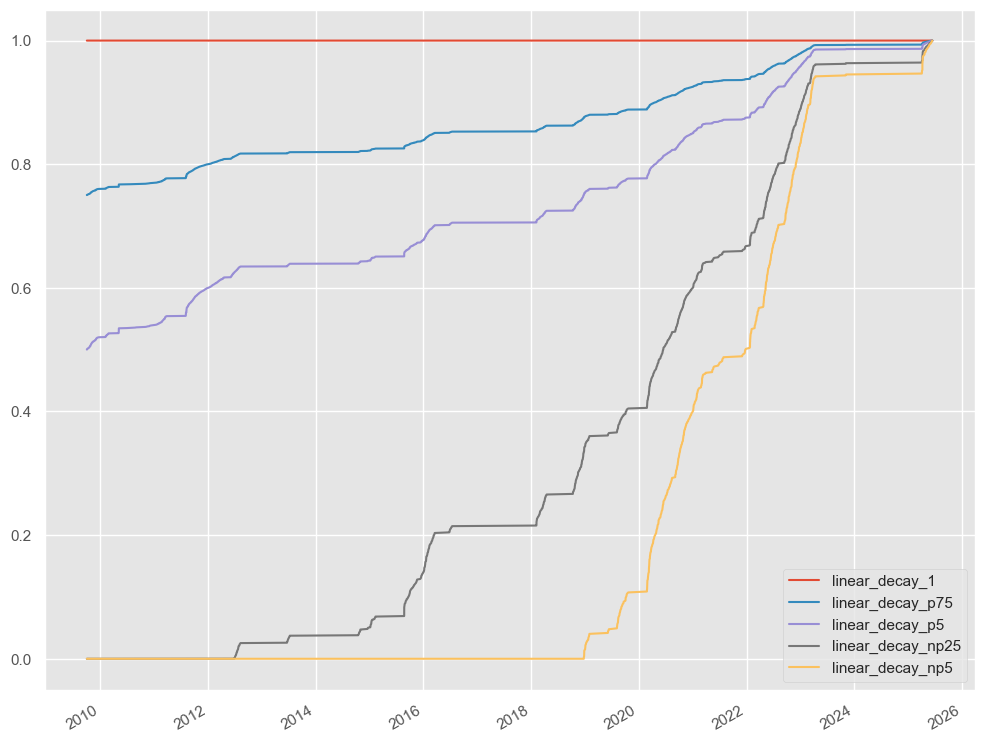

In [347]:
decay_factor_linear_df.plot(figsize=(12,10))

<Axes: >

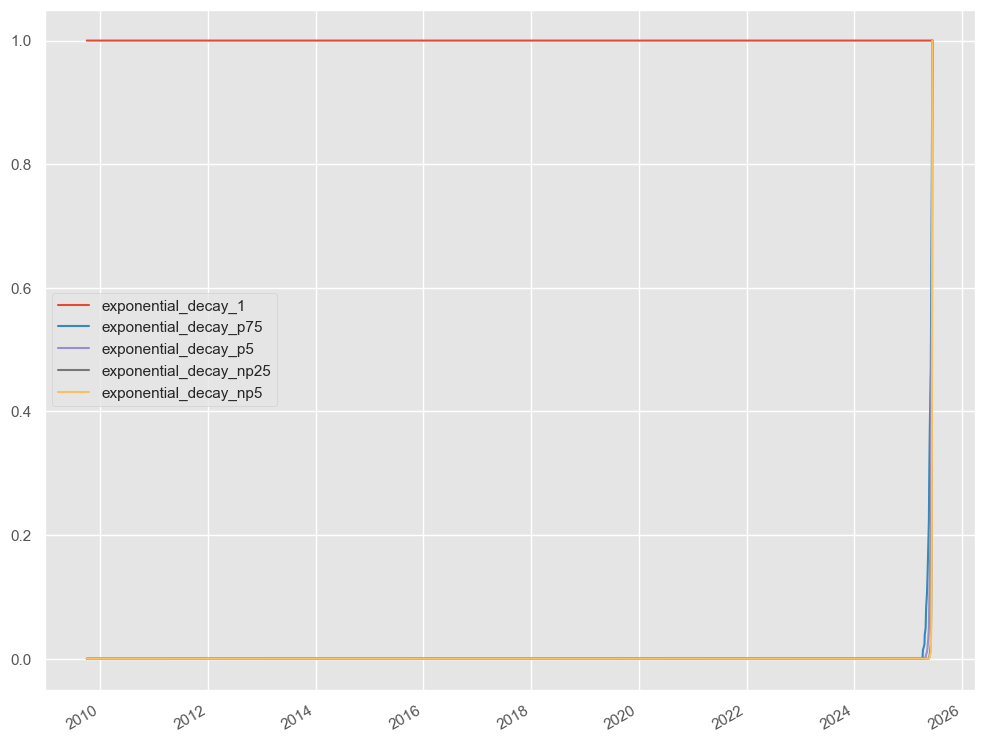

In [348]:
decay_factor_exp_df.plot(figsize=(12,10))

## 5. Consider you have applied meta-labels to events determined by a trendfollowing model. Suppose that two thirds of the labels are 0 and one third of the labels are 1.

### a. What happens if you fit a classifier without balancing class weights?

The model will bias toward the class 0, since it will learn more features from this class.

### b. A label 1 means a true positive, and a label 0 means a false positive. By  applying balanced class weights, we are forcing the classifier to pay more attention to the true positives, and less attention to the false positives. Why does that make sense?

We can enforce the classifier to pay more attention on the true positive label, so that it won't be biased on the false positive.

### c. What is the distribution of the predicted labels, before and after applying  balanced class weights?

In [352]:
# Trend-following strategy: moving average crossover
# 1. Compute short-term and long-term moving averages
short_window = 50
long_window = 200

short_ma = close.rolling(window=short_window, min_periods=1).mean()
long_ma = close.rolling(window=long_window, min_periods=1).mean()

# 2. Generate signals DataFrame with column name 'side'
signal = pd.DataFrame(index=close.index)
signal['side'] = 0
signal.loc[short_ma > long_ma, 'side'] = 1
signal.loc[short_ma < long_ma, 'side'] = -1

# Remove look-ahead bias by lagging the signal
signal['side'] = signal['side'].shift(1)

daily_vol = get_daily_vol(close, span0=10000)
t_events = symmetric_cusum_filter(close, daily_vol)
vertical_bars = get_vertical_bars(close, t_events, num_days=1) # t1 in the text book

abs_return = close.pct_change().abs()
events = get_events(close, t_events=t_events, pt_sl=[1,1], t1=vertical_bars, num_threads=1, target=daily_vol, min_ret=0.01, side=signal['side'])

concurrent_events = mpPandasObj(mp_num_concurrent_events, pdObj=('molecule', events.index), numThreads=1, close_idx=close.index, t1=events['t1'])
concurrent_events = concurrent_events.loc[~concurrent_events.index.duplicated(keep='last')]
concurrent_events = concurrent_events.reindex(close.index).fillna(0)

average_uniqueness = mpPandasObj(mp_sample_tw, pdObj=('molecule', events.index), numThreads=1, t1=events['t1'], concurrent_events=concurrent_events)
mean_average_uniqueness = average_uniqueness.mean()

# get the labels
bins = get_bins(events, close)
bins['bin'].value_counts()

bin
0    1240
1     371
Name: count, dtype: int64

In [353]:

# Log Returns
dollar_bars['log_ret'] = np.log(close).diff()
dollar_bars['log_t1'] = dollar_bars['log_ret'].shift(1)
# prevent look-ahead bias
shifted_price = close.shift(1)

# Momentum
dollar_bars['mom2'] = shifted_price.pct_change(periods=2)
dollar_bars['mom3'] = shifted_price.pct_change(periods=3)
dollar_bars['mom4'] = shifted_price.pct_change(periods=4)
dollar_bars['mom5'] = shifted_price.pct_change(periods=5)

# Volatility
dollar_bars['volatility_50'] = dollar_bars['log_t1'].rolling(window=50, min_periods=50, center=False).std()
dollar_bars['volatility_31'] = dollar_bars['log_t1'].rolling(window=31, min_periods=31, center=False).std()
dollar_bars['volatility_15'] = dollar_bars['log_t1'].rolling(window=15, min_periods=15, center=False).std()

# Serial Correlation (Takes about 4 minutes)
window_autocorr = 50

dollar_bars['autocorr_1'] = dollar_bars['log_t1'].rolling(window=window_autocorr, min_periods=window_autocorr, center=False).apply(lambda x: x.autocorr(lag=1), raw=False)
dollar_bars['autocorr_2'] = dollar_bars['log_t1'].rolling(window=window_autocorr, min_periods=window_autocorr, center=False).apply(lambda x: x.autocorr(lag=2), raw=False)
dollar_bars['autocorr_3'] = dollar_bars['log_t1'].rolling(window=window_autocorr, min_periods=window_autocorr, center=False).apply(lambda x: x.autocorr(lag=3), raw=False)
dollar_bars['autocorr_4'] = dollar_bars['log_t1'].rolling(window=window_autocorr, min_periods=window_autocorr, center=False).apply(lambda x: x.autocorr(lag=4), raw=False)
dollar_bars['autocorr_5'] = dollar_bars['log_t1'].rolling(window=window_autocorr, min_periods=window_autocorr, center=False).apply(lambda x: x.autocorr(lag=5), raw=False)

# Get the various log -t returns
dollar_bars['log_t2'] = dollar_bars['log_ret'].shift(2)
dollar_bars['log_t3'] = dollar_bars['log_ret'].shift(3)
dollar_bars['log_t4'] = dollar_bars['log_ret'].shift(4)
dollar_bars['log_t5'] = dollar_bars['log_ret'].shift(5)

In [356]:
# Biased tree

# prepare train and test data
# Get features at event dates
feature_cols = ["volatility_50", "volatility_31", "volatility_15", "autocorr_1", "autocorr_2", "autocorr_3", "autocorr_4", "autocorr_5", "log_t1", "log_t2", "log_t3", "log_t4", "log_t5", "mom2", "mom3", "mom4", "mom5"]

rf_biased = RandomForestClassifier(
    n_estimators=512, random_state=42, max_depth=5, oob_score=True, class_weight='balanced_subsample')

X = dollar_bars.loc[events.index][feature_cols]
y = bins['bin']

kfold = KFold(n_splits=5)
accuracies = []
for train_index, test_index in kfold.split(X):
    rf_biased.fit(X.iloc[train_index], y.iloc[train_index])
    y_pred = rf_biased.predict(X.iloc[test_index])
    accuracies.append(accuracy_score(y.iloc[test_index], y_pred))
    
print("Confusion matrix:")
print(confusion_matrix(y.iloc[test_index], y_pred))
print()
print("Original report:")
print(classification_report(y.iloc[test_index], y_pred))
print()
print("The mean accuracy of k-fold cross-validation is %.3f." % np.mean(accuracies))

Confusion matrix:
[[207  36]
 [ 64  15]]

Original report:
              precision    recall  f1-score   support

           0       0.76      0.85      0.81       243
           1       0.29      0.19      0.23        79

    accuracy                           0.69       322
   macro avg       0.53      0.52      0.52       322
weighted avg       0.65      0.69      0.66       322


The mean accuracy of k-fold cross-validation is 0.667.


In [357]:
# Unbiased tree

rf_unbiased = RandomForestClassifier(
    n_estimators=512, random_state=42, max_depth=5, oob_score=True, class_weight='balanced_subsample')

kfold = KFold(n_splits=5)
accuracies = []
for train_index, test_index in kfold.split(X):
    rf_unbiased.fit(X.iloc[train_index], y.iloc[train_index])
    y_pred = rf_unbiased.predict(X.iloc[test_index])
    accuracies.append(accuracy_score(y.iloc[test_index], y_pred))


print("-- Balanced class weights --")
print("Confusion matrix:")
print(confusion_matrix(y.iloc[test_index], y_pred))
print()
print("Classification report:")
print(classification_report(y.iloc[test_index], y_pred))
print()
print("The mean accuracy of k-fold cross-validation is %.3f." % np.mean(accuracies))
print()
print("The distribution of labels:")
print(pd.Series(y_pred).value_counts(normalize=True))

-- Balanced class weights --
Confusion matrix:
[[207  36]
 [ 64  15]]

Classification report:
              precision    recall  f1-score   support

           0       0.76      0.85      0.81       243
           1       0.29      0.19      0.23        79

    accuracy                           0.69       322
   macro avg       0.53      0.52      0.52       322
weighted avg       0.65      0.69      0.66       322


The mean accuracy of k-fold cross-validation is 0.667.

The distribution of labels:
0    0.841615
1    0.158385
Name: proportion, dtype: float64


## 6. Update the draw probabilities for the final draw in Section 4.5.3.

In [ ]:
def get_ind_matrix(bar_idx, t1):
    # Get indicator matrix
    ind_matrix = pd.DataFrame(0, index=bar_idx, columns=range(t1.shape[0]))
    for i, (t0, t1) in enumerate(t1.items()):
        ind_matrix.loc[t0:t1, i] = 1.0
    return ind_matrix


def get_avg_uniqueness(ind_matrix):
    # Average uniqueness from indicator matrix
    concurrency = ind_matrix.sum(axis=1) # concurrency
    uniqueness = ind_matrix.div(concurrency, axis=0) # uniqueness
    avg_uniqueness = uniqueness[uniqueness>0].mean()
    return avg_uniqueness

In [ ]:
tl = pd.Series([2, 3, 5], index=[0, 2, 4])
bar_idx = range(tl.max() + 1)
indicator_matrix = get_ind_matrix(bar_idx, tl)
print(f"Indicator matrix: \n{indicator_matrix}\n")

picked = [1, 2]
averages = []
for i in indicator_matrix:
    print(f"i: {i}")
    avg_uniqueness = get_avg_uniqueness(indicator_matrix[picked + [i]])
    averages.append(avg_uniqueness.iloc[-1])
averages = pd.Series(averages) / sum(averages)
print("Probabilities:")
print(averages)

Indicator matrix: 
   0  1  2
0  1  0  0
1  1  0  0
2  1  1  0
3  0  1  0
4  0  0  1
5  0  0  1

i: 0
i: 1
i: 2
Probabilities:
0    0.454545
1    0.272727
2    0.272727
dtype: float64


## 7. In Section 4.5.3, suppose that number 2 is picked again in the second draw.  What would be the updated probabilities for the third draw?

In [392]:
picked = [1, 1]
averages = []
for i in indicator_matrix:
    avg_uniqueness = get_avg_uniqueness(indicator_matrix[picked + [i]])
    averages.append(avg_uniqueness.iloc[-1])
averages = pd.Series(averages) / sum(averages)
print("Probabilities:")
print(averages)

Probabilities:
0    0.368421
1    0.157895
2    0.473684
dtype: float64
